# Augmented GACC — $\gamma_{T^*}$ over the MCMC-augmented dataset

This notebook computes the **augmented generalised accuracy** $\gamma_{T^*}(\widetilde{\mathcal{N}}^b)$
over the dataset $T^* = T \cup \bigcup_{\mathbf{x}\in T} T_{\mathbf{x}}$ introduced in Šíma & Cabessa (ICONIP 2026).

**Key difference from `plot_volumes_v3k.ipynb`:**  
The augmented representatives in $T_{\mathbf{x}}$ were generated using the **4-bit** q-model's equivalence
classes.  For other bit-widths $b$, some representatives may fall in the **same** P2 cell as their
origin $\mathbf{x}_0$, contributing no new coverage.  This notebook optionally filters those out
per bit-width using a pre-computed diversity index
(`data/fashionMNIST_aug_diversity_{NETWORK}.json`, generated by `scripts/build_aug_diversity.py`).

**Requires** (from the project root):
```bash
# 1. Generate diversity index (fast — activation-pattern checks only)
python scripts/build_aug_diversity.py --model_type mlp
python scripts/build_aug_diversity.py --model_type cnn

# 2. Volume results for augmented points (from Vit's cluster run)
#    results/volumes_v3k_{NETWORK}_aug/volumes_sample*.json
#    + copied originals: volumes_orig_sample*.json  (3 files already present for MLP)
```

**Containment:** $P_1(\mathbf{x}) \supseteq P_2(\mathbf{x}) \supseteq P_3^{(k)}(\mathbf{x})$

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json, math, os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

# === CHOOSE THE MODEL === #
NETWORK  = "mlp"   # mlp / cnn
DEVICE   = torch.device("cpu")
SAVE_PDF = True

# === FILTER AUGMENTED POINTS PER BIT-WIDTH ===
# True  → for each b, only count augmented points that lie in a DIFFERENT P2 cell
#         from their x0 under the b-bit model (requires diversity index, see above).
# False → use all available augmented records for every b (simpler, but mixes
#         4-bit-diverse points into higher-bit evaluations).
USE_DIVERSITY_FILTER = True

RESULTS_DIR_AUG = ROOT / "results" / f"volumes_v3k_{NETWORK}_aug"
RESULTS_DIR_T   = ROOT / "results" / f"volumes_v3k_{NETWORK}"   # for original T (0-199)
DIVERSITY_FILE  = ROOT / "data"    / f"fashionMNIST_aug_diversity_{NETWORK}.json"

print("Project root    :", ROOT)
print("Aug results dir :", RESULTS_DIR_AUG)
print("USE_DIVERSITY_FILTER:", USE_DIVERSITY_FILTER)

Project root    : /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes
Aug results dir : /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_v3k_mlp_aug
USE_DIVERSITY_FILTER: True


## Load results and diversity index

## Sanity checks on the augmented dataset

In [2]:
"""
Sanity checks — run before any GACC computation.
All assertions should pass; failures indicate a dataset or pipeline problem.

Checks:
  1. Augmented point count matches the log file.
  2. No augmented point is pixel-identical to its x0 (non-collapse).
  3. FP model classifies every augmented point as the correct class (100% acc).
  4. [requires diversity file] b=4 diversity = 100%  (by construction of the walk).
"""

from src.models.networks       import FashionMLP_Large, FashionCNN_Small
from src.quantization.quantize import quantize_model
from src.optim.mcmc_augment    import activation_pattern

# ── paths ─────────────────────────────────────────────────────────────────────
TAG          = "seed42_walk_aug200"
AUG_DATA     = ROOT / "data" / f"fashionMNIST_augmented_{NETWORK}_{TAG}.pt"
AUG_LOG      = ROOT / "data" / f"fashionMNIST_augmented_{NETWORK}_{TAG}_log.json"
ORIG_DATA    = ROOT / "data" / f"fashionMNIST_correct_{NETWORK}.pt"
CKPT         = ROOT / "checkpoints" / f"fashion_{NETWORK}_best.pth"

# ── load ──────────────────────────────────────────────────────────────────────
with open(AUG_LOG) as f:
    aug_log = json.load(f)

dataset_aug  = torch.load(AUG_DATA,  weights_only=False)
dataset_orig = torch.load(ORIG_DATA, weights_only=False)

model_cls = FashionCNN_Small if NETWORK == "cnn" else FashionMLP_Large
fp_model  = model_cls()
fp_model.load_state_dict(torch.load(CKPT, weights_only=True, map_location=DEVICE))
fp_model.eval()

def prep(x):
    """Batch-dimension input for the model."""
    return (x.flatten().unsqueeze(0) if NETWORK == "mlp"
            else (x.unsqueeze(0) if x.dim() == 3 else x.unsqueeze(0).unsqueeze(0))).to(DEVICE)

# ── build orig→aug mapping from log ───────────────────────────────────────────
orig_to_aug = {}
cursor = 0
for i, n in enumerate(aug_log["reps_per_sample"]):
    orig_to_aug[i] = list(range(cursor, cursor + n))
    cursor += n

# ── CHECK 1: point count ───────────────────────────────────────────────────────
n_aug = len(dataset_aug)
assert n_aug == aug_log["n_augmented"], \
    f"FAIL count: dataset has {n_aug} pts, log says {aug_log['n_augmented']}"
print(f"[OK] Check 1 — augmented point count: {n_aug}")

# ── CHECK 2: non-collapse (L∞ distance to x0 > 0) ────────────────────────────
n_collapse = 0
for orig_idx, aug_indices in orig_to_aug.items():
    x0 = dataset_orig[orig_idx][0].flatten().numpy()
    for ai in aug_indices:
        x_aug = dataset_aug[ai][0].flatten().numpy()
        if np.max(np.abs(x_aug - x0)) == 0.0:
            n_collapse += 1
assert n_collapse == 0, f"FAIL non-collapse: {n_collapse} augmented points identical to x0"
print(f"[OK] Check 2 — non-collapse: 0 augmented points identical to their x0")

# ── CHECK 3: FP model accuracy = 100% ─────────────────────────────────────────
n_wrong = 0
with torch.no_grad():
    for x_aug, c_aug in dataset_aug:
        pred = int(fp_model(prep(x_aug)).argmax(dim=1).item())
        if pred != int(c_aug):
            n_wrong += 1
assert n_wrong == 0, f"FAIL FP accuracy: {n_wrong}/{n_aug} misclassified"
print(f"[OK] Check 3 — FP model accuracy: {n_aug}/{n_aug} correct (100%)")

# ── CHECK 4: b=4 diversity = 100% (requires diversity file) ───────────────────
if DIVERSITY_FILE.exists():
    with open(DIVERSITY_FILE) as f:
        div = json.load(f)
    n_diverse_4 = len(div["diverse_per_bit"]["4"])
    assert n_diverse_4 == n_aug, \
        f"FAIL b=4 diversity: only {n_diverse_4}/{n_aug} points diverse under 4-bit model"
    print(f"[OK] Check 4 — b=4 diversity: {n_diverse_4}/{n_aug} (100% by construction)")
else:
    print(f"[SKIP] Check 4 — diversity file not found, run build_aug_diversity.py first")

print("\nAll checks passed.")

[OK] Check 1 — augmented point count: 8235
[OK] Check 2 — non-collapse: 0 augmented points identical to their x0
[OK] Check 3 — FP model accuracy: 8235/8235 correct (100%)
[OK] Check 4 — b=4 diversity: 8235/8235 (100% by construction)

All checks passed.


In [3]:
# ── Load augmented-point volume results ───────────────────────────────────────
records_aug = []
for f in sorted(RESULTS_DIR_AUG.glob("volumes_sample*.json"),
                key=lambda p: int(p.stem.replace("volumes_sample", ""))):
    with open(f) as fh:
        records_aug.append(json.load(fh))
print(f"Augmented results loaded : {len(records_aug)}")

# ── From diversity file, find which originals issued the loaded aug points ─────
# orig_to_aug: {"0": [0..35], "1": [36..71], ...}
with open(DIVERSITY_FILE) as f:
    _div = json.load(f)

aug_to_orig = {}
for orig_str, aug_indices in _div["orig_to_aug"].items():
    for ai in aug_indices:
        aug_to_orig[ai] = int(orig_str)

loaded_aug_indices = {r["sample_idx"] for r in records_aug}
orig_indices_needed = sorted({aug_to_orig[ai] for ai in loaded_aug_indices})
print(f"Original samples that issued these aug points : {orig_indices_needed}")

# ── Load those original T results from RESULTS_DIR_T ─────────────────────────
records_orig = []
for idx in orig_indices_needed:
    f = RESULTS_DIR_T / f"volumes_sample{idx}.json"
    if f.exists():
        with open(f) as fh:
            records_orig.append(json.load(fh))
    else:
        print(f"  [WARNING] {f.name} not found in {RESULTS_DIR_T.name}")
print(f"Original T results loaded : {len(records_orig)} / {len(orig_indices_needed)}")

records_all = records_orig + records_aug
bits_grid   = records_all[0]["bits_grid"]
print(f"Total T* records          : {len(records_all)}  "
      f"({len(records_aug)} aug + {len(records_orig)} orig)")
print(f"bits_grid                 : {bits_grid}")

# ── Load diversity index (per-bit diverse aug indices) ────────────────────────
diverse_aug_per_bit = None
if USE_DIVERSITY_FILTER:
    diverse_aug_per_bit = {int(k): set(v) for k, v in _div["diverse_per_bit"].items()}
    print(f"\nDiversity index loaded from {DIVERSITY_FILE.name}:")
    print(f"  {'b':>4}  {'diverse aug':>12}  {'/ total aug':>12}")
    for b in bits_grid:
        n_div = len(diverse_aug_per_bit.get(b, []))
        print(f"  {b:4d}  {n_div:12d}  {_div['n_augmented']:12d}")


Augmented results loaded : 100
Original samples that issued these aug points : [0, 1, 2]
Original T results loaded : 3 / 3
Total T* records          : 103  (100 aug + 3 orig)
bits_grid                 : [4, 6, 8, 10, 12, 16]

Diversity index loaded from fashionMNIST_aug_diversity_mlp.json:
     b   diverse aug   / total aug
     4          8235          8235
     6          7987          8235
     8          7237          8235
    10          4011          8235
    12          1115          8235
    16           154          8235


## Compute augmented GACC $\gamma_{T^*}$

$$
\gamma_{T^*}(b) = \frac{\displaystyle\sum_{\mathbf{y}\in T^*_{\text{div}}(b)} V_3^{(c_{\mathbf{y}})}(\mathbf{y},b)}{\displaystyle\sum_{\mathbf{y}\in T^*_{\text{div}}(b)} \sum_{k} V_3^{(k)}(\mathbf{y},b)}
$$

where $T^*_{\text{div}}(b)$ = original $T$ + augmented points in a **different P2 cell** from their $\mathbf{x}_0$ under the $b$-bit model (when `USE_DIVERSITY_FILTER=True`),
or $T^*$ = all loaded records (when `USE_DIVERSITY_FILTER=False`).

In [4]:
def compute_augmented_gacc(records, bits_grid, diverse_aug_per_bit=None):
    """
    Compute γ_{T*}(b) for each bit-width.

    Parameters
    ----------
    records            : list of JSON dicts (from volumes_v3k pipeline)
    bits_grid          : list of bit-widths
    diverse_aug_per_bit: dict {b: set of aug sample_idx} or None.
        If not None, augmented records are included in the sum for bit-width b
        ONLY IF their sample_idx is in diverse_aug_per_bit[b].
        Original T records (data_path contains 'correct') are always included.

    Returns
    -------
    gamma        : (len(bits_grid),) array
    n_records_used : dict {b: count of records contributing to the sum}
    n_zero_num   : list, #records where V3_c = 0
    """
    sum_num   = {b: 0.0 for b in bits_grid}
    sum_denom = {b: 0.0 for b in bits_grid}
    n_used    = {b: 0   for b in bits_grid}
    n_zero    = {b: 0   for b in bits_grid}

    for r in records:
        is_aug  = "augmented" in r["data_path"]
        aug_idx = r["sample_idx"]  # only meaningful for aug records
        c       = r["class_c"]

        for b in bits_grid:
            # Diversity filter: skip augmented records not in this b's diverse set
            if (is_aug
                    and diverse_aug_per_bit is not None
                    and aug_idx not in diverse_aug_per_bit.get(b, set())):
                continue

            widths_k = r["widths_both"][str(b)]
            v3_c     = widths_k[c]
            v3_sum   = sum(widths_k)

            sum_num[b]   += v3_c
            sum_denom[b] += v3_sum
            n_used[b]    += 1
            if v3_c == 0.0 or math.isnan(v3_c):
                n_zero[b] += 1

    gamma = np.array([
        sum_num[b] / sum_denom[b] if sum_denom[b] > 0 else float("nan")
        for b in bits_grid
    ])
    return gamma, n_used, [n_zero[b] for b in bits_grid]


gamma_aug, n_used, n_zero = compute_augmented_gacc(
    records_all, bits_grid, diverse_aug_per_bit
)

print("Augmented GACC γ_{T*} per bit-width:")
filt_label = "(diversity filter ON)" if diverse_aug_per_bit is not None else "(no filter)"
print(f"  {filt_label}")
print(f"  {'bits':>5}  {'γ_{T*}':>10}  {'#records used':>14}  {'#V3_c=0':>10}")
for i, b in enumerate(bits_grid):
    print(f"  {b:5d}  {gamma_aug[i]:10.6f}  {n_used[b]:14d}  {n_zero[i]:10d}")

Augmented GACC γ_{T*} per bit-width:
  (diversity filter ON)
   bits      γ_{T*}   #records used     #V3_c=0
      4    1.000000             103           0
      6    1.000000             102           0
      8    1.000000              94           0
     10    1.000000              43           0
     12    1.000000              17           0
     16    1.000000               3           0


## Compare: with vs without diversity filter

In [5]:
# Compute both versions for comparison
gamma_filtered,   _, _ = compute_augmented_gacc(records_all, bits_grid, diverse_aug_per_bit)
gamma_unfiltered, _, _ = compute_augmented_gacc(records_all, bits_grid, None)

print(f"{NETWORK.upper()} — augmented GACC comparison:")
print(f"  {'bits':>5}  {'γ (filtered)':>14}  {'γ (all aug)':>12}  {'diff':>10}")
for i, b in enumerate(bits_grid):
    diff = gamma_filtered[i] - gamma_unfiltered[i]
    print(f"  {b:5d}  {gamma_filtered[i]:14.6f}  {gamma_unfiltered[i]:12.6f}  {diff:+10.6f}")

MLP — augmented GACC comparison:
   bits    γ (filtered)   γ (all aug)        diff
      4        1.000000      1.000000   +0.000000
      6        1.000000      1.000000   +0.000000
      8        1.000000      1.000000   +0.000000
     10        1.000000      1.000000   +0.000000
     12        1.000000      1.000000   +0.000000
     16        1.000000      1.000000   +0.000000


## Plot — $\gamma_{T^*}$ vs bit-width

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/plot_gacc_augmented_mlp.pdf


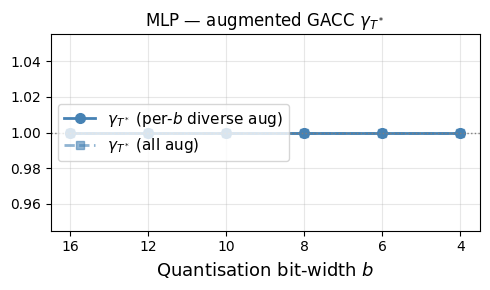

In [6]:
x = np.arange(len(bits_grid))

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(x, gamma_filtered[::-1],   marker="o", linewidth=2, markersize=7,
        color="steelblue",
        label=r"$\gamma_{T^*}$ (per-$b$ diverse aug)")
ax.plot(x, gamma_unfiltered[::-1], marker="s", linewidth=2, markersize=6,
        color="steelblue", linestyle="--", alpha=0.6,
        label=r"$\gamma_{T^*}$ (all aug)")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("Quantisation bit-width $b$", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bits_grid.__reversed__())
ax.legend(fontsize=11, loc="center left")
ax.grid(True, alpha=0.3)
ax.set_title(f"{NETWORK.upper()} — augmented GACC $\\gamma_{{T^*}}$", fontsize=12)

plt.tight_layout()
if SAVE_PDF:
    out = ROOT / "results" / "figures" / f"plot_gacc_augmented_{NETWORK}.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, bbox_inches="tight")
    print(f"Saved to {out}")
plt.show()

## Diversity coverage — how many augmented points are diverse per bit-width?

Augmented points were generated using the **4-bit** q-model's equivalence classes.  
For higher bit-widths the q-model has fewer distinct activation patterns within P1,  
so more augmented points fall back into x0's P2 cell and are filtered out.

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/plot_aug_diversity_mlp.pdf


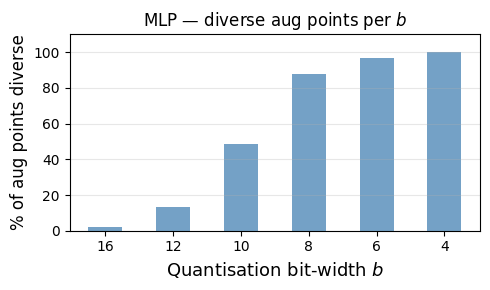


MLP — 8235 total augmented points:
     b     diverse         %
     4        8235    100.0%
     6        7987     97.0%
     8        7237     87.9%
    10        4011     48.7%
    12        1115     13.5%
    16         154      1.9%


In [7]:
if diverse_aug_per_bit is not None:
    n_total_aug = _div["n_augmented"]
    counts = [len(diverse_aug_per_bit.get(b, [])) for b in bits_grid]
    pcts   = [100 * c / n_total_aug for c in counts]

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(len(bits_grid)), pcts[::-1], color="steelblue", alpha=0.75, width=0.5)
    ax.set_xlabel("Quantisation bit-width $b$", fontsize=13)
    ax.set_ylabel("% of aug points diverse", fontsize=12)
    ax.set_xticks(range(len(bits_grid)))
    ax.set_xticklabels(bits_grid.__reversed__())
    ax.set_ylim(0, 110)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_title(f"{NETWORK.upper()} — diverse aug points per $b$", fontsize=12)

    plt.tight_layout()
    if SAVE_PDF:
        out = ROOT / "results" / "figures" / f"plot_aug_diversity_{NETWORK}.pdf"
        out.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out, bbox_inches="tight")
        print(f"Saved to {out}")
    plt.show()

    print(f"\n{NETWORK.upper()} — {n_total_aug} total augmented points:")
    print(f"  {'b':>4}  {'diverse':>10}  {'%':>8}")
    for b, c, p in zip(bits_grid, counts, pcts):
        print(f"  {b:4d}  {c:10d}  {p:7.1f}%")
else:
    print("No diversity index loaded — run build_aug_diversity.py first.")